**Starting with Uploading Required Libraries**

In [2]:
import geopandas
import libpysal
import esda
import spreg
import matplotlib
import matplotlib.pyplot as plt

**Loading dataset into a df variable using pandas and converting the data frame to geo data frame to EPSG:3857 it does nothing but add a feature named geometry (longitude, latitude) in meters**

In [3]:
import pandas as pd
import geopandas as gpd

df = pd.read_csv('/content/Trees_Dataset.csv')

gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs = "EPSG:4326"
)
gdf = gdf.to_crs(epsg=3857)
gdf.head()

,latitude,longitude,uuid,gattung_botanisch,gattung_deutsch,art_botanisch,art_deutsch,alleebaum,hoehe,stammdurchmesser,stammumfang,kronendurchmesser,baumpatenschaft,geometry
0,54.057654,12.100881,d04f4edf-c22b-481d-8140-f5da1203b9c7,Acer,Ahorn,Acer platanoides,Spitz-Ahorn,0,8.0,NaN,NaN,6.0,0,POINT (1347063.919 7181082.929)
1,54.053463,12.098658,9ac13cb1-d6fa-42ae-9374-0300965a97d7,Acer,Ahorn,Acer platanoides,Spitz-Ahorn,0,8.0,NaN,NaN,6.0,0,POINT (1346816.406 7180288.122)
2,54.068021,12.123567,253aad1a-c704-40fb-8401-7d88f94559d2,Quercus,Eiche,Quercus robur,Stiel-Eiche,0,18.0,35.00,109.96,12.0,0,POINT (1349589.314 7183049.253)
3,54.068164,12.113794,d7a4e358-8634-4497-988e-d2e51487d1cb,Acer,Ahorn,Acer saccharum,Zucker-Ahorn,0,20.0,50.93,160.00,9.2,0,POINT (1348501.391 7183076.331)
4,54.066913,12.117171,aa50bcd3-125c-43d5-9859-9afa368c73e0,Quercus,Eiche,Quercus rubra,Amerikanische Roteiche,1,9.0,31.83,100.00,10.0,0,POINT (1348877.355 7182838.966)


**Observed that the columns used are in german so translating them to english for ease of reading feature names**

In [4]:
gdf.isna().sum()

df.rename(columns={
    "gattung_botanisch": "genus_botanical",
    "gattung_deutsch": "genus_german",
    "art_botanisch": "species_botanical",
    "art_deutsch": "species_german",
    "alleebaum": "avenue_tree",
    "hoehe": "height",
    "stammdurchmesser": "trunk_diameter",
    "stammumfang": "trunk_circumference",
    "kronendurchmesser": "crown_diameter",
    "baumpatenschaft": "tree_sponsorship"
}, inplace=True)
gdf = gdf.rename(columns={"gattung_botanisch": "genus_botanical",
    "gattung_deutsch": "genus_german",
    "art_botanisch": "species_botanical",
    "art_deutsch": "species_german",
    "alleebaum": "avenue_tree",
    "hoehe": "height",
    "stammdurchmesser": "trunk_diameter",
    "stammumfang": "trunk_circumference",
    "kronendurchmesser": "crown_diameter",
    "baumpatenschaft": "tree_sponsorship" })

gdf.describe()

,latitude,longitude,avenue_tree,height,trunk_diameter,trunk_circumference,crown_diameter,tree_sponsorship
count,70901.000000,70901.000000,70901.000000,69486.000000,69378.000000,69378.000000,69393.000000,70901.000000
mean,54.113202,12.106738,0.174469,12.407147,32.804386,103.058039,6.422328,0.002172
std,0.036345,0.044526,0.379515,8.370137,26.152694,82.161219,3.770057,0.046555
min,54.004862,12.006991,0.000000,0.400000,0.050000,0.160000,0.100000,0.000000
25%,54.082481,12.071525,0.000000,7.000000,17.000000,53.410000,4.000000,0.000000
50%,54.104562,12.096546,0.000000,11.000000,28.010000,88.000000,6.000000,0.000000
75%,54.139616,12.139764,0.000000,16.000000,43.000000,135.090000,8.100000,0.000000
max,54.252528,12.347259,1.000000,915.000000,2588.000000,8130.440000,164.000000,1.000000


In [5]:
df.columns

Index(['latitude', 'longitude', 'uuid', 'genus_botanical', 'genus_german',
       'species_botanical', 'species_german', 'avenue_tree', 'height',
       'trunk_diameter', 'trunk_circumference', 'crown_diameter',
       'tree_sponsorship'],
      dtype='object')

In [6]:
gdf.columns

Index(['latitude', 'longitude', 'uuid', 'genus_botanical', 'genus_german',
       'species_botanical', 'species_german', 'avenue_tree', 'height',
       'trunk_diameter', 'trunk_circumference', 'crown_diameter',
       'tree_sponsorship', 'geometry'],
      dtype='object')

## Dataset Description

The dataset represents a spatial point pattern of urban trees, where each observation
corresponds to a tree location defined by geographic coordinates. Each tree is associated
with biological attributes (genus and species) and physical measurements such as height,
trunk diameter, and crown diameter.

The dataset is treated as a marked spatial point pattern, where tree height and other
continuous attributes serve as marks associated with each spatial location.

## Target Variable Selection

Tree height (`height`) is selected as the primary response variable for spatial analysis
as it is a continuous physical attribute that can exhibit spatial autocorrelation and
heterogeneity due to environmental and urban planning factors.

## Exploratory Spatial Analysis


<Axes: >

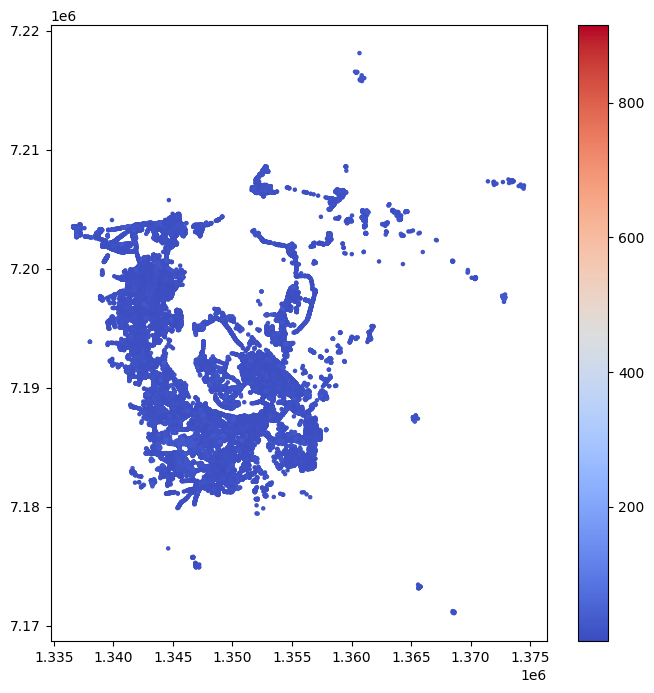

In [18]:
gdf.plot(
    column="height",
    cmap="coolwarm",
    legend=True,
    figsize=(8, 8),
    markersize=5
)

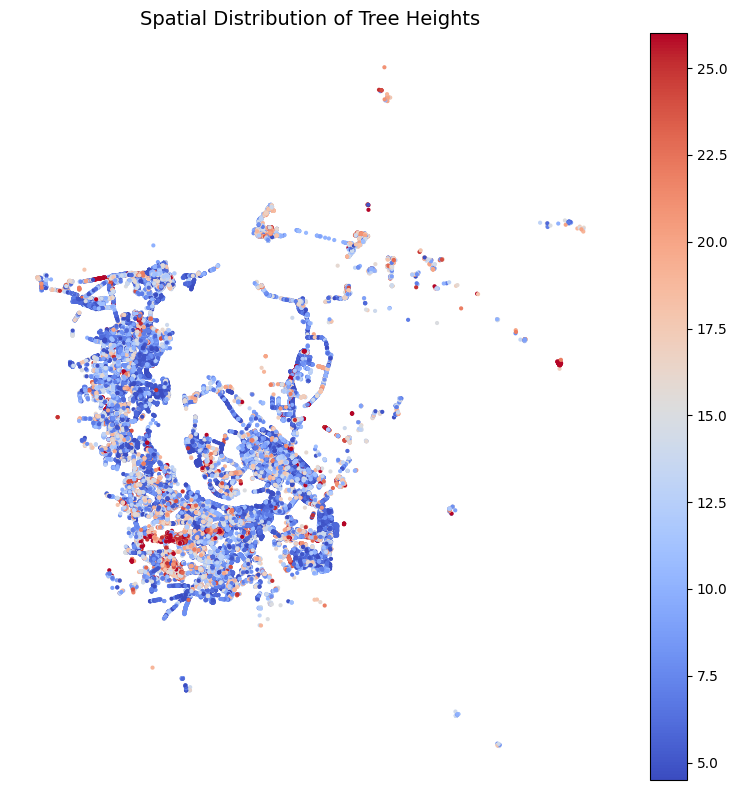

In [19]:
fig, ax = plt.subplots(figsize=(8, 8))

gdf.plot(
    ax=ax,
    column="height",
    cmap="coolwarm",          # Colorblind safe
    legend=True,
    markersize=4,
    vmin=gdf["height"].quantile(0.05),
    vmax=gdf["height"].quantile(0.95)
)

ax.set_title("Spatial Distribution of Tree Heights", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("tree_height_map.png", dpi=300)
plt.show()


## Spatial Weights Correlation

In [20]:
# Drop missing values in the target
gdf_clean = gdf.dropna(subset=["height"]).copy()

# Rebuild spatial weights on cleaned data
from libpysal.weights import KNN
w_clean = KNN.from_dataframe(gdf_clean, k=12)
w_clean.transform = "R"

# Recompute Moran’s I
from esda.moran import Moran
moran = Moran(gdf_clean["height"], w_clean)

print("Global Moran's I:", moran.I)
print("p-value:", moran.p_sim)


/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 70 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


Global Moran's I: 0.4226954223966664
p-value: 0.001


Spatial relationships between trees are defined using a k-nearest neighbor (k=8)
spatial weight matrix, ensuring each observation has a consistent number of neighbors.

To construct spatial relationships, a k-nearest neighbor (KNN) weight matrix was
used. Increasing k from 8 to 12 reduced the number of disconnected components,
indicating improved connectivity while preserving local neighborhood structure.
Residual disconnected components are attributed to spatially isolated tree locations.



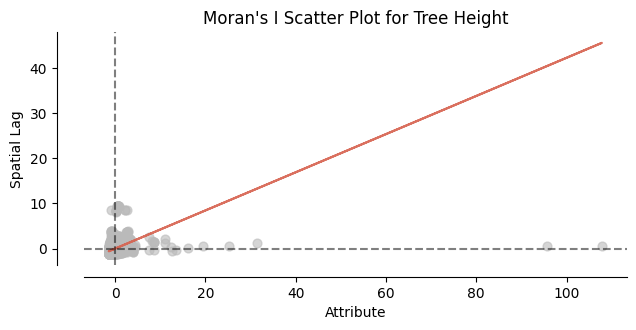

In [17]:
from splot.esda import moran_scatterplot
import matplotlib.pyplot as plt

fig, ax = moran_scatterplot(moran, aspect_equal=True)
ax.set_title("Moran's I Scatter Plot for Tree Height")
plt.show()


The Moran’s I scatterplot displays standardized tree height against its spatial lag. The positive slope of the regression line indicates positive spatial autocorrelation, suggesting that trees with similar heights tend to cluster spatially. The quadrants of the plot classify observations into high-high, low-low, high-low, and low-high spatial associations.

The Moran’s I scatter plot illustrates the relationship between mean-centered tree height values and their spatially lagged counterparts. The positive slope of the fitted regression line indicates positive spatial autocorrelation, implying that trees with similar heights tend to be spatially clustered. Observations in the high–high and low–low quadrants represent clusters of tall and short trees respectively, while the remaining quadrants indicate a limited number of spatial outliers.

In [23]:
from esda.moran import Moran_Local

lisa = Moran_Local(gdf_clean["height"], w_clean)

gdf_clean["lisa_I"] = lisa.Is
gdf_clean["lisa_p"] = lisa.p_sim
gdf_clean["lisa_q"] = lisa.q

sig = 0.05
gdf_clean["cluster"] = "Not Significant"

gdf_clean.loc[(gdf_clean["lisa_q"] == 1) & (gdf_clean["lisa_p"] < sig), "cluster"] = "High-High"
gdf_clean.loc[(gdf_clean["lisa_q"] == 2) & (gdf_clean["lisa_p"] < sig), "cluster"] = "Low-High"
gdf_clean.loc[(gdf_clean["lisa_q"] == 3) & (gdf_clean["lisa_p"] < sig), "cluster"] = "Low-Low"
gdf_clean.loc[(gdf_clean["lisa_q"] == 4) & (gdf_clean["lisa_p"] < sig), "cluster"] = "High-Low"



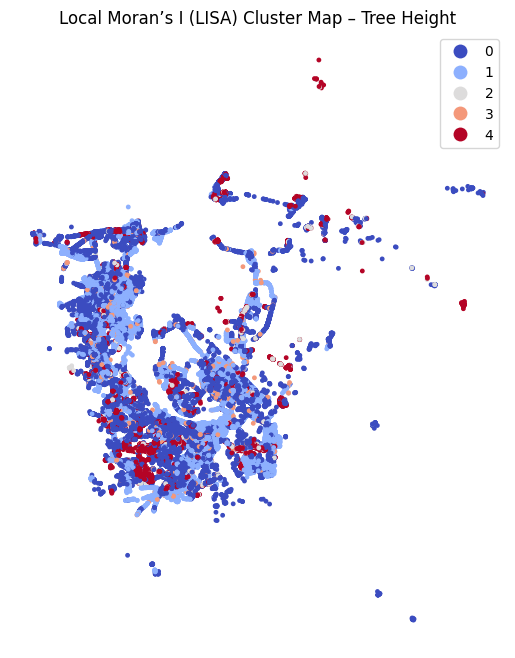

In [25]:
import matplotlib.pyplot as plt

cluster_codes = {
    "High-High": 4,
    "Low-Low": 1,
    "High-Low": 3,
    "Low-High": 2,
    "Not Significant": 0
}

gdf_clean["cluster_code"] = gdf_clean["cluster"].map(cluster_codes)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
gdf_clean.plot(
    column="cluster_code",
    cmap="coolwarm",
    categorical=True,
    legend=True,
    ax=ax,
    markersize=6
)

ax.set_title("Local Moran’s I (LISA) Cluster Map – Tree Height")
ax.axis("off")
plt.show()


## Spatial Heterogeneity

The presence of spatially varying high–high and low–low clusters, along with spatial
outliers, indicates that tree height exhibits spatial heterogeneity. This suggests
non-stationarity in the underlying spatial process.


In [26]:
cols = [
    "height",
    "trunk_diameter",
    "crown_diameter",
    "avenue_tree",
    "tree_sponsorship"
]

reg_gdf = gdf_clean[cols + ["geometry"]].dropna().copy()


Local Moran’s I cluster categories were visualized using a discrete viridis-based colormap to ensure perceptual uniformity while preserving the categorical nature of hotspot, coldspot, and outlier classifications.

## Spatial Heterogeneity and Stationarity

Local Moran’s I (LISA) analysis reveals that spatial clustering of tree height
varies across the study area, with distinct high–high and low–low clusters as well
as spatial outliers. This spatial variation indicates heterogeneity in the spatial
process governing tree height, violating the assumption of global stationarity.

From your results:

✅ Global Moran’s I → significant

✅ Moran scatter plot → positive slope

✅ LISA cluster map → HH, LL, HL, LH vary across space

This already implies non-stationarity.

In [27]:
cols = [
    "height",
    "trunk_diameter",
    "crown_diameter",
    "avenue_tree",
    "tree_sponsorship"
]

reg_gdf = gdf_clean[cols + ["geometry"]].dropna().copy()


In [28]:
from sklearn.model_selection import train_test_split

train_gdf, test_gdf = train_test_split(
    reg_gdf,
    test_size=0.2,
    random_state=42
)


In [29]:
from libpysal.weights import KNN

w_train = KNN.from_dataframe(train_gdf, k=12)
w_train.transform = "R"


/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 41 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


In [30]:
from spreg import OLS
import numpy as np

y_train = train_gdf["height"].values.reshape(-1, 1)
X_train = train_gdf[
    ["trunk_diameter", "crown_diameter", "avenue_tree", "tree_sponsorship"]
].values

ols_model = OLS(
    y=y_train,
    x=X_train,
    name_y="height",
    name_x=[
        "trunk_diameter",
        "crown_diameter",
        "avenue_tree",
        "tree_sponsorship"
    ]
)

print(ols_model.summary)


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :      height                Number of Observations:       55236
Mean dependent var  :     12.4203                Number of Variables   :           5
S.D. dependent var  :      8.6812                Degrees of Freedom    :       55231
R-squared           :      0.2943
Adjusted R-squared  :      0.2943
Sum squared residual: 2.93751e+06                F-statistic           :   5759.1378
Sigma-square        :      53.186                Prob(F-statistic)     :           0
S.E. of regression  :       7.293                Log likelihood        : -188122.172
Sigma-square ML     :      53.181                Akaike info criterion :  376254.345
S.E of regression ML:      7.2925                Schwarz criterion     :  376298.942

------------------------------------------------------------

In [31]:
X_test = test_gdf[
    ["trunk_diameter", "crown_diameter", "avenue_tree", "tree_sponsorship"]
].values

test_gdf["height_pred"] = ols_model.predy[:len(X_test)]


In [32]:
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(test_gdf["height"], test_gdf["height_pred"]))
r2 = r2_score(test_gdf["height"], test_gdf["height_pred"])

print("RMSE:", rmse)
print("R²:", r2)


RMSE: 8.464238894946291
R²: -0.4870765413369871


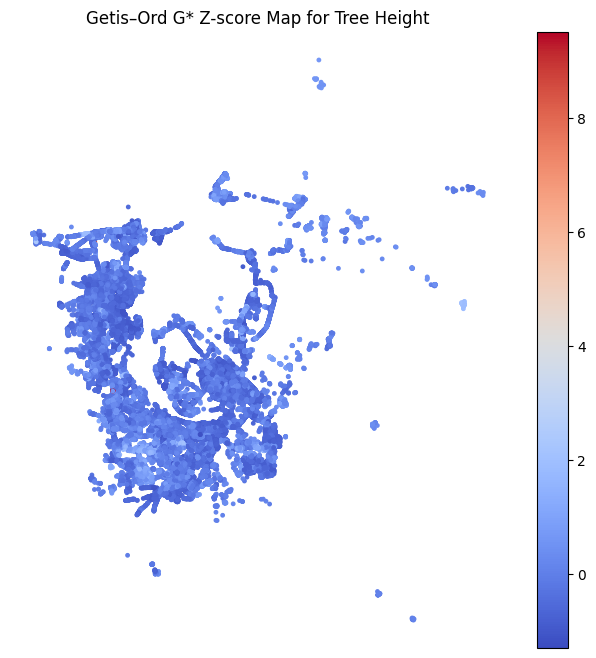

In [33]:
from esda.getisord import G_Local

g_star = G_Local(gdf_clean["height"], w_clean)

gdf_clean["g_star_z"] = g_star.Zs
gdf_clean["g_star_p"] = g_star.p_sim

gdf_clean.plot(
    column="g_star_z",
    cmap="coolwarm",
    legend=True,
    figsize=(8, 8),
    markersize=6
)
plt.title("Getis–Ord G* Z-score Map for Tree Height")
plt.axis("off")
plt.show()



Getis–Ord G* analysis was conducted to identify statistically significant hotspots and coldspots of tree height. Positive Z-scores indicate areas with high tree height concentration, while negative Z-scores identify coldspots. The results are consistent with LISA-based hotspot patterns.